In [1]:
import numpy as np
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import interp1d
import plotly.graph_objects as go
from scipy.linalg import eigh, eig
import matplotlib.pyplot as plt
import pandas as pd
import time
from dataclasses import dataclass
import pickle
import inputs
from inputs import (
    L, sep_dur, n_tot, dof_malla, g,
    a_r, gamma_r, q0, m_r, e_r, nu, i_r, k_b, c_b,
    dano_nodal, gdl_restringidos,
    tren_params, cinematica_params, sim_params, carga_params,
    t_eval, t_sim
)

from utils.logger import log_inputs

log_file = log_inputs(inputs)


✔ Parámetros guardados en:
  resultados/logs/run_2026-01-13_23-40-58.json
  resultados/logs/run_2026-01-13_23-40-58.txt


In [2]:
class MallaRiel:
    def __init__(self, L, n_tot, dof, nodo_i=0):
        """
        Clase para generar la geometría de una viga.

        Args:
            L: (float) Longitud total de la viga [m].
            n_tot: (int) Cantidad total de nodos
            dof: (int) Grados de libertad por nodo.
            nodo_i: (float) Coordenada del nodo inicial (por defecto es 0.00)
        """
        self.L = L
        self.n_tot = n_tot
        self.dof = dof
        self.nodo_i = nodo_i
        self.coord_fin = nodo_i + L

        # Geometría
        self.coord_nodos = self.generar_nodos()

        # Conectividad entre elementos
        self.conect = self.conectar_barras()
        self.ne = self.conect.shape[0]  # Numero de elementos

        # Geometría
        self.long_elem = self.calcular_longitudes_barras()
        self.theta = self.calcular_angulos_barras()

    def generar_nodos(self) -> np.ndarray:
        """
        Genera las coordenadas de los nodos de la vía.

            salida: Arreglo de dimensión (self.n_tot x 2) con las coordenadas de los nodos.
        """
        x_coords = np.linspace(self.nodo_i, self.coord_fin, self.n_tot)
        y_coords = np.zeros(self.n_tot)  # Suponemos que todos los nodos están en y=0
        return np.column_stack((x_coords, y_coords))

    def conectar_barras(self) -> np.ndarray:
        """
        Genera la matriz de conectividad de las barras del riel.

            salida: Matriz de conectividad de las barras llamada "conect".
        """
        conect = [[i, i + 1] for i in range(len(self.coord_nodos) - 1)]
        return np.array(conect)

    def calcular_longitudes_barras(self) -> np.ndarray:
        """
        Calcula las longitudes de las barras entre nodos consecutivos.

            salida: Arreglo con las longitudes de las barras.
        """
        coord_bar = np.concatenate((self.coord_nodos[self.conect[:, 0]], self.coord_nodos[self.conect[:, 1]]), axis=1)
        return np.sqrt((coord_bar[:, 3] - coord_bar[:, 1]) ** 2 + (coord_bar[:, 2] - coord_bar[:, 0]) ** 2)

    def calcular_angulos_barras(self) -> np.ndarray:
        """
        Calcula los ángulos de las barras con respecto a la horizontal.

            salida: Arreglo con los ángulos de las barras.
        """
        coord_bar = np.concatenate((self.coord_nodos[self.conect[:, 0]], self.coord_nodos[self.conect[:, 1]]), axis=1)
        return np.arctan2((coord_bar[:, 3] - coord_bar[:, 1]), (coord_bar[:, 2] - coord_bar[:, 0]))

    def __repr__(self):
        """
        Representación textual de la geometría de la vía.
        """
        return (
            f"MallaViga(L={self.L}, Le={self.long_elem}, dof_malla={self.dof}, nodo_i={self.nodo_i})\n"
            f"Número de nodos: {self.n_tot}\n"
            f"Número de barras: {len(self.conect)}"
        )

In [3]:
class PropGeomMecViga:
    def __init__(self, m_r, a_r, e_r, gamma_r, i_r, k_b, c_b):
        """
            Clase para cargar las propiedades geométricas y mecánicas de la viga

            Args:
                m_r: masa por unidad de longitud del riel [Kg / m]
                a_r: área de la sección transversal del riel [m²]
                e_r: Módulo de Young del material (acero) [Pa]
                nu: Coeficiente de Poisson del material (acero)
                gamma_r: Masa específica del material (acero) [Kg / m³]
                i_r: Momento de inercia del perfil [m⁴]
                k_b: Rigidez del resorte de apoyo (conjunto balasto-durmiente) [N / m²]
                c_b: Coeficiente de amortiguamiento (conjunto balasto-durmiente) [N s / m]
        """

        self.m_r = m_r
        self.a_r = a_r
        self.e_r = e_r
        self.gamma_r = gamma_r
        self.i_r = i_r
        self.k_b = k_b
        self.c_b = c_b

In [4]:
class ElementoViga:
    def __init__(self, obj_malla, obj_prop_mecanicas, q_func, q0):
        """
            Crea los elementos finitos tipo viga de Euler-Bernoulli.
            Además de calcular las matrices de masa y rigidez.

            Args:
                obj_malla: Objeto creado con la clase MallaRiel
                obj_prop_mecanicas: Objeto creado con la clase PropGeomMecViga
                q_func: función de carga
        """
        # Geometría de la malla
        self.malla = obj_malla
        self.coord_nodos = obj_malla.generar_nodos()
        self.conect = obj_malla.conect
        self.ne = obj_malla.ne
        
        # Propiedades mecánicas por elemento

        self.E = obj_prop_mecanicas.e_r
        self.A = obj_prop_mecanicas.a_r
        self.Ix = obj_prop_mecanicas.i_r
        self.gamma_r = obj_prop_mecanicas.gamma_r
        self.k_b = obj_prop_mecanicas.k_b
        self.c_b = obj_prop_mecanicas.c_b

        # Carga distribuida

        self.q = q_func  # Carga distribuida sobre el elemento
        self.q0 = q0        # ESCALAR

        # Dimensiones del problema

        self.nn = obj_malla.n_tot
        self.ngdl = obj_malla.dof * self.nn  # obj_malla.dof (3) por nodo: axial, desp transversal y giro

        # --------------------------------------------------
        # Rigidez nodal equivalente del balasto
        # --------------------------------------------------
        self.k_b_nodo = np.zeros(self.nn)

        # Nodo inicial
        self.k_b_nodo[0] = self.k_b[0]

        # Nodos interiores
        for i in range(1, self.nn - 1):
            self.k_b_nodo[i] = 0.5 * (self.k_b[i - 1] + self.k_b[i])

        # Nodo final
        self.k_b_nodo[-1] = self.k_b[-1]

        self.k_b_nodo_base = self.k_b_nodo.copy()
        # --------------------------------------------------
        # Amortiguamiento nodal equivalente del balasto
        # --------------------------------------------------
        self.c_b_nodo = np.zeros(self.nn)

        self.c_b_nodo[0] = self.c_b[0]

        for i in range(1, self.nn - 1):
            self.c_b_nodo[i] = 0.5 * (self.c_b[i - 1] + self.c_b[i])

        self.c_b_nodo[-1] = self.c_b[-1]


    def mat_N_axial(self, xi):
        return np.array([1 - xi, xi])

    def mat_dN_axial(self):
        return np.array([-1, 1])

    def mat_N_desp_giro(self, e, xi):
        """
              Funcion para calcular la matriz N de funciones de forma
                  Args:
                    e: Elemento en cuestión
                    xi: coordenada del punto de Gauss para integración
        """
        Le = self.malla.long_elem[e]

        N1 = 1 / 4 * (2 + xi) * (1 - xi) ** 2
        N2 = Le / 8 * (1 + xi) * (1 - xi) ** 2
        N3 = 1 / 4 * (2 - xi) * (1 + xi) ** 2
        N4 = Le / 8 * (xi - 1) * (1 + xi) ** 2
        return np.array([0, N1, N2, 0, N3, N4])

    def mat_dN_desp_giro(self, e, xi):
        """
            Funcion para calcular la matriz N de derivadas primeras de funciones de forma
                Args:
                    e: Elemento en cuestión
                    xi: coordenada del punto de Gauss para integración
        """
        Le = self.malla.long_elem[e]

        dxi_dx = 2.0 / Le
        dN1 = 3 / 4 * (xi ** 2 - 1)
        dN2 = Le / 8 * (3 * xi ** 2 - 2 * xi - 1)
        dN3 = 3 / 4 * (1 - xi ** 2)
        dN4 = Le / 8 * (3 * xi ** 2 + 2 * xi - 1)
        return dxi_dx * np.array([0, dN1, dN2, 0, dN3, dN4])

    def mat_B(self, e, xi):
        """
              Funcion para calcular la matriz B de derivadas segundas de funciones de forma

                Args:
                    e: Elemento en cuestión
                    xi: coordenada del punto de Gauss para integración
        """

        Le = self.malla.long_elem[e]

        d2xi_dx2 = (2.0 / Le) ** 2
        B1 = 3 / 2 * xi
        B2 = Le / 4 * (3 * xi - 1)
        B3 = - 3 / 2 * xi
        B4 = Le / 4 * (3 * xi + 1)

        return d2xi_dx2 * np.array([B1, B2, B3, B4])

    def mat_masa_elemento(self, e, A, gamma_r, I_rho=0.0):
        """
        Calcula la matriz de masas consistente para un elemento de viga Euler-Bernoulli
        con 3 GDL por nodo: [u, w, theta] en cada nodo.
            Args:

            e: Elemento en cuestión
            A: área de la sección transversal [m²]
            gamma_r: densidad del material [kg/m³]
            I_rho: momento de inercia rotacional por unidad de longitud [kg·m] (opcional)
                      Se usa para masa asociada a la rotación theta.
        salida: matriz de masas (6x6)
        """
        Le = self.malla.long_elem[e]
        gp = 4  # puntos de Gauss
        puntos, pesos = np.polynomial.legendre.leggauss(gp)

        m_elemento = np.zeros((self.malla.dof * 2, self.malla.dof * 2))

        for xi, w in zip(puntos, pesos):
            # --- Funciones de forma ---
            N = self.mat_N_desp_giro(e, xi)  # [N1, N2, N3, N4] Hermite
            # Axial (lineales)
            Nu = np.array([1 - (xi + 1) / 2, (xi + 1) / 2])

            # --- Matriz de forma total (6x6) ---
            # Orden: [u1, w1, theta1, u2, w2, theta2]
            N_total = np.zeros((3, 6))

            # Axial
            N_total[0, 0] = Nu[0]
            N_total[0, 3] = Nu[1]

            # Transversal
            N_total[1, 1] = N[1]
            N_total[1, 2] = N[2]
            N_total[1, 4] = N[4]
            N_total[1, 5] = N[5]

            if I_rho > 0.0:
                N_total[2, 2] = N[1]
                N_total[2, 5] = N[3]

            m_part = gamma_r * A * (N_total[0:2, :].T @ N_total[0:2, :])
            if I_rho > 0.0:
                m_part += gamma_r * I_rho * (N_total[2:3, :].T @ N_total[2:3, :])

            m_elemento += m_part * (Le / 2) * w

        return m_elemento
        
    def mat_rig_elemento(self, e, A, E, I):
        """
        Calcula la matriz de rigidez de un elemento de viga Timoshenko
        utilizando funciones de forma y cuadratura de Gauss.

            salida: matriz de rigidez del elemento (6,6)
        """
        Le = self.malla.long_elem[e]
        gp = 2
        puntos, pesos = np.polynomial.legendre.leggauss(gp)

        k_elemento = np.zeros([self.malla.dof * 2, self.malla.dof * 2])

        for xi, w in zip(puntos, pesos):
            # N = self.mat_N_desp_giro(e, xi)
            B = self.mat_B(e, xi)

            # --- Matrices B ---
            # Axial
            Ba = np.array([-1 / Le, 0, 0, 1 / Le, 0, 0])

            # Flexión
            Bb = np.array([0, B[0], B[1], 0, B[2], B[3]])

            # --- Contribuciones ---
            Ka = E * A * np.outer(Ba, Ba)
            Kb = E * I * np.outer(Bb, Bb)

            
            J = Le / 2

            # --- Suma ---
            k_elemento += w * (Ka + Kb) * J

        return k_elemento

    def vector_fuerza_elemental(self, e):
        """
        Calcula el vector de fuerzas nodales equivalentes para una carga distribuida q_func(x)
        utilizando funciones de forma y cuadratura de Gauss.

            Args:

                e: Elemento en cuestión
            salida: vector de fuerzas nodales del elemento (4,)
        """

        ni, nj = self.conect[e]
        xi_nodo = self.coord_nodos[ni, 0]
        xj_nodo = self.coord_nodos[nj, 0]
        Le = self.malla.long_elem[e]

        gp = 4

        puntos, pesos = np.polynomial.legendre.leggauss(gp)

        f_elemento = np.zeros(6)

        for xi, w in zip(puntos, pesos):
            # Transformación de coordenadas naturales a físicas

            x = ((1 - xi) * xi_nodo + (1 + xi) * xj_nodo) / 2  # Mapeo lineal desde xi ∈ [-1, 1]

            # Evaluar q_func en x
            qx = self.q(x, self.q0)

            # Evaluar funciones de forma en xi
            N = self.mat_N_desp_giro(e, xi)

            Nv_w = np.array([0, N[1], N[2], 0, N[4], N[5]])

            # Jacobiano del cambio de variable
            J = Le / 2

            # Si qx es escalar (carga vertical uniforme/distribuida)
            if np.isscalar(qx) or np.ndim(qx) == 0:
                f_elemento += w * Nv_w * qx * J
            else:
                # Si qx es vector (6,) hacer producto punto
                f_elemento += w * Nv_w * (Nv_w @ qx) * J

        return f_elemento
    
    def aplicar_dano_durmientes(self, dano_nodal=None):
        """
        dano_nodal : dict {nodo: factor}
            factor ∈ (0,1]
            1.0 → sano
            0.3 → 70% de pérdida de rigidez
        """

        # Estado sano
        self.k_b_nodo = self.k_b_nodo_base.copy()

        if dano_nodal is None:
            return

        for nodo, factor in dano_nodal.items():
            self.k_b_nodo[nodo] *= factor


    def ensamblar_matrices_globales(self):

        K_global = np.zeros((self.ngdl, self.ngdl))
        M_global = np.zeros((self.ngdl, self.ngdl))
        C_global = np.zeros((self.ngdl, self.ngdl))
        f_global = np.zeros(self.ngdl)

        for e, (ni, nj) in enumerate(self.conect):

            # Propiedades del elemento
            E = self.E
            I = self.Ix
            A = self.A
            gamma_r = self.gamma_r

            # # Chequear si este elemento está dañado
            # factor_elem = 1.0
            # if elementos_danados and e in elementos_danados:
            #     factor_elem = elementos_danados[e]

            k_e = self.mat_rig_elemento(e, A[e], E[e], I[e])
            m_e = self.mat_masa_elemento(e, A[e], gamma_r[e], I_rho=0.0)
            f_elem = self.vector_fuerza_elemental(e)

            # DOFs locales: [u_i, w_i, θ_i, u_j, w_j, θ_j] → mapeo global
            dofs_locales = [
                self.malla.dof * ni,  # u_i
                self.malla.dof * ni + 1,  # w_i
                self.malla.dof * ni + 2,  # θ_i
                self.malla.dof * nj,  # u_j
                self.malla.dof * nj + 1,  # w_j
                self.malla.dof * nj + 2  # θ_j
            ]

            # Ensamblado en matriz global
            for i_local, Iglob in enumerate(dofs_locales):
                for j_local, Jglob in enumerate(dofs_locales):
                    K_global[Iglob, Jglob] += k_e[i_local, j_local]
                    M_global[Iglob, Jglob] += m_e[i_local, j_local]

                f_global[Iglob] += f_elem[i_local]

        # Aplico resortes y amortiguadores a los gdl verticales de la vía

        for nodo in range(self.nn):
            gdl_w = self.malla.dof * nodo + 1
            K_global[gdl_w, gdl_w] += self.k_b_nodo[nodo]
        
            C_global[gdl_w, gdl_w] += self.c_b_nodo[nodo]
            
        return K_global, M_global, C_global, f_global

    def frecuencias_propias(self, K, M, n_modes=10, tol=1e-6):
        """
        Calcula las frecuencias propias (rad/s) del sistema FEM.

        Devuelve solo modos dinámicos, evitando los de cuerpo rígido (ω > tol).
        """
        # autovalores generalizados
        vals, _ = np.linalg.eig(np.linalg.solve(M, K))

        # quedarnos con reales y positivos
        vals = np.real(vals)
        vals = vals[vals > tol]

        omegas = np.sqrt(np.sort(vals))

        if len(omegas) < 2:
            raise ValueError("No hay suficientes modos dinámicos")

        return omegas[:n_modes]
        
    def coeficientes_rayleigh(self, omegas, zetas, idx_modes=(0, 2)):
        """
        Calcula α y β a partir de dos modos.

        omegas : array de frecuencias (rad/s)
        zetas  : array o lista [ζ1, ζ2]
        idx_modes : índices de los modos a usar
        """
        i, j = idx_modes

        if i >= len(omegas) or j >= len(omegas):
            raise ValueError("Índices de modos fuera de rango")

        wi = omegas[i]
        wj = omegas[j]

        A = np.array([
            [1/(2*wi), wi/2],
            [1/(2*wj), wj/2]
        ])

        zeta = np.asarray(zetas)

        alpha, beta = np.linalg.solve(A, zeta)

        return alpha, beta


    
    def calcular_rayleigh(self, K, M, zeta_obj=(0.01, 0.01), n_modes=10, idx_modes=(0, 2)):
        """
        Calcula y guarda los coeficientes de Rayleigh del sistema sano.
        """
        omegas = self.frecuencias_propias(K, M, n_modes=n_modes)

        alpha, beta = self.coeficientes_rayleigh(
            omegas,
            zeta_obj,
            idx_modes=idx_modes
        )

        
        self.alpha_rayleigh = alpha
        self.beta_rayleigh = beta
        self.omegas_rayleigh = omegas

        return alpha, beta, omegas
    
    def calculo_C(self, K, M, alpha, beta):
        """
            Calcula la matriz global de amortiguamiento de Rayleigh.

            Parameters
            ----------
            K : np.ndarray
                Matriz de rigidez global.
            M : np.ndarray
                Matriz de masa global.
            alpha, beta : coeficientes
        """
        
        C = alpha * M + beta * K
        return C

    def aplicar_condiciones_borde(self, K, M, C, f, gdl_restringidos):
        """
            Reduce el sistema eliminando los grados de libertad restringidos.

            Args.
            ----------
            K : np.ndarray
                Matriz de rigidez global.
            M : np.ndarray
                Matriz de masa global.
            C : Matriz de amortiguamiento de Rayleigh
            f : np.ndarray
                Vector de fuerzas global.
            gdl_restringidos : list o array
                Índices de los grados de libertad restringidos.

            Salida
            -------
            K_red, M_red, C_red, f_red : matrices y vector reducidos
            gdl_libres : np.ndarray
                Índices de los grados de libertad libres.
            """

        # Asegurar que sea un array ordenado
        gdl_restringidos = np.array(sorted(gdl_restringidos), dtype=int)

        # Índices libres (complemento)
        gdl_totales = np.arange(K.shape[0])
        gdl_libres = np.setdiff1d(gdl_totales, gdl_restringidos)

        # Reducción
        K_red = K[np.ix_(gdl_libres, gdl_libres)]
        M_red = M[np.ix_(gdl_libres, gdl_libres)]
        C_red = C[np.ix_(gdl_libres, gdl_libres)]
        f_red = f[gdl_libres]

        return K_red, M_red, C_red, f_red

In [5]:
class CargaMovil:
    """
    Modelo de carga móvil tren–vía.
    Acopla ejes (2 GDL por eje) con la vía (malla FEM).
    """

    def __init__(self, *,
                 P,
                 n_vagones, n_ejes,
                 m1, m2,
                 k1, k2,
                 c1, c2,
                 K_via, C_via, M_via,
                 coord_nodos, conect,
                 dof_malla, x0, Le,
                 d1, d2, d3,
                 elemento_viga):
        """
        Todo lo que NO depende del tiempo.
        """

        # --- Parámetros generales ---
        self.P = P
        self.n_vagones = n_vagones
        self.n_ejes = n_ejes

        self.m1 = m1
        self.m2 = m2
        self.k1 = k1
        self.k2 = k2
        self.c1 = c1
        self.c2 = c2

        self.coord_nodos = coord_nodos
        self.conect = conect
        self.n_elem = len(self.conect)
        self.dof_malla = dof_malla
        self.x0 = x0
        self.Le = Le
        self.elemento_viga = elemento_viga

        self.d1 = d1
        self.d2 = d2
        self.d3 = d3

        # --- Tamaños ---
        self.gdl_ejes = n_vagones * n_ejes * 2
        self.gdl_via = K_via.shape[0]
        self.tam = self.gdl_ejes + self.gdl_via
        
        # --- Guardar vía ---
        self.K_via = K_via
        self.C_via = C_via

        # --- Submatrices de un eje ---
        self.k_eje = np.array([[k1, -k1],
                               [-k1, k1 + k2]], dtype=float)

        self.c_eje = np.array([[c1, -c1],
                               [-c1, c1 + c2]], dtype=float)

        # --- Parte constante de K y C ---
        self.K_base = np.zeros((self.tam, self.tam))
        self.C_base = np.zeros((self.tam, self.tam))
        self.F_base = np.zeros(self.tam)

        self._ensamblar_parte_constante()
        self.M_via = M_via
        self.M = self.masa_global()

    def masa_global(self):
        """
        Construye la matriz de masa global del sistema acoplado
        (ejes + vía). Se calcula UNA SOLA VEZ.
        """

        M = np.zeros((self.tam, self.tam))

        # --- Masas de los ejes ---
        for i in range(self.gdl_ejes):
            if i % 2 == 0:
                M[i, i] = self.m1
            else:
                M[i, i] = self.m2

        # --- Masa de la vía ---
        M[self.gdl_ejes:, self.gdl_ejes:] = self.M_via

        return M

    def _ensamblar_parte_constante(self):
        """Ensamblado que NO depende de la posición del tren"""

        # --- Ejes ---
        for ej in range(self.n_vagones * self.n_ejes):
            idx = 2 * ej
            self.K_base[idx:idx + 2, idx:idx + 2] += self.k_eje
            self.C_base[idx:idx + 2, idx:idx + 2] += self.c_eje

            # Peso
            self.F_base[idx] = -self.m1 * 9.81
            self.F_base[idx + 1] = -self.m2 * 9.81

        # --- Vía ---
        self.K_base[self.gdl_ejes:, self.gdl_ejes:] = self.K_via
        self.C_base[self.gdl_ejes:, self.gdl_ejes:] = self.C_via
        # print(f'Matriz de rigidez casi acoplada: {self.K_base[self.gdl_ejes, self.gdl_ejes]}')
        # np.savetxt("K.txt", self.K_base, fmt="%.6e")
    # ------------------------------------------------------------------

    def _posiciones_ejes(self, x_c):
        """Devuelve una lista plana con todas las posiciones de los ejes"""
        posiciones = []

        for vagon in range(self.n_vagones):
            base1 = self.d3 - ((vagon + 1) * self.d3 + vagon * self.d2)
            base2 = self.d3 - ((vagon + 1) * self.d3 + (vagon + 1) * self.d2)

            if self.n_ejes >= 1:
                posiciones.append(base1 + self.d1 / 2 + x_c)

            if self.n_ejes >= 2:
                posiciones.append(base1 - self.d1 / 2 + x_c)

            if self.n_ejes >= 3:
                posiciones.append(base2 + self.d1 / 2 + x_c)

            if self.n_ejes >= 4:
                posiciones.append(base2 - self.d1 / 2 + x_c)

            if self.n_ejes >= 5:
                posiciones.append(base1 - 2 * self.d2 + self.d1 / 2 + x_c)

            if self.n_ejes == 6:
                posiciones.append(base1 - 2 * self.d2 - self.d1 / 2 + x_c)
        
        return posiciones
    
    def localizar_elemento(self, x):
        """
        Dada una posición x, devuelve:
        e, ni, nj, x1, x2

        Si x está fuera de la vía, devuelve None.
        """
        for e, (ni, nj) in enumerate(self.conect):
            x1 = self.coord_nodos[ni][0]
            x2 = self.coord_nodos[nj][0]

            if x1 <= x <= x2 or x2 <= x <= x1:
                return e, ni, nj, x1, x2

        return None
    
    def evaluar(self, x_c):
        """
        Evalúa el sistema acoplado para una posición del tren x_c.
        Este es el único método que se llama desde el solver.
        """

        # Copias (para no destruir las bases)
        K = self.K_base.copy()
        C = self.C_base.copy()
        F = self.F_base.copy()
        
        pos_ejes = self._posiciones_ejes(x_c)
        # print(pos_ejes)
        # --- Acoplamiento eje–vía ---

        for i, x_eje in enumerate(pos_ejes):
            idx_eje = 2 * i + 1  # GDL vertical del eje
            loc = self.localizar_elemento(x_eje)
            if loc is None:
                continue

            e, ni, nj, x1, x2 = loc

            # coordenada natural
            xi = 2 * (x_eje - x1) / (x2 - x1) - 1

            # funciones de forma
            N = self.elemento_viga.mat_N_desp_giro(e, xi)

            # DOF vía (verticales)
            idx_vi = self.gdl_ejes + ni * self.dof_malla + 1
            idx_vj = self.gdl_ejes + nj * self.dof_malla + 1

            k = self.k2
            K[idx_vi, idx_eje] += -k * N[1]
            K[idx_vj, idx_eje] += -k * N[4]
            

            K[idx_eje, idx_vi] += -k * N[1]
            K[idx_eje, idx_vj] += -k * N[4]

            K[idx_vi, idx_vi] += k * N[1]
            K[idx_vj, idx_vj] += k * N[4]

            # -----------------------------------------
            # ACOPLAMIENTO DE AMORTIGUAMIENTO (C)
            # -----------------------------------------
            c = self.c2

            C[idx_vi, idx_eje] += -c * N[1]
            C[idx_vj, idx_eje] += -c * N[4]

            C[idx_eje, idx_vi] += -c * N[1]
            C[idx_eje, idx_vj] += -c * N[4]

            C[idx_vi, idx_vi] += c * N[1]
            C[idx_vj, idx_vj] += c * N[4]

            P = self.P   # carga vertical por eje (positiva hacia abajo)

            # Fuerzas nodales equivalentes en la vía
            F[idx_vi] += P * N[1]
            F[idx_vj] += P * N[4]

        return F, K, C

In [6]:
class SistemaViaVehiculo:
    def __init__(self, via, tren, sim, cinem, m_inv):
        self.via = via
        self.tren = tren
        self.sim = sim
        self.cinem = cinem
        self.m_inv = m_inv
        self.ndof = m_inv.shape[0]

    def rhs(self, t, y):
        w = y[:self.ndof]
        dw = y[self.ndof:]

        x_c = self.cinem.posicion(t)
        F, K, C = self.tren.evaluar(x_c)

        return np.hstack((dw, self.m_inv @ (F - C @ dw - K @ w)))

In [7]:
@dataclass
class ParametrosTren:
    n_vagones: int
    n_ejes: int
    m1: float
    m2: float
    k1: float
    k2: float
    c1: float
    c2: float
    d1: float
    d2: float
    d3: float
    g: float = 9.81

    @property
    def P(self):
        return -(self.m1 + self.m2) * self.g


@dataclass
class ParametrosVia:
    K: np.ndarray
    M: np.ndarray
    C: np.ndarray
    f: np.ndarray
    coord_nodos: np.ndarray
    conect: np.ndarray
    dof_malla: int

@dataclass
class ParametrosSimulacion:
    t_eval: np.ndarray
    T_rampa: float

Perfil de velocidad

In [8]:
def _perfil_velocidad(t, tipo, v0, v1, t_total, t_acc, t_crucero):
    v = np.zeros_like(t)

    if tipo == "constante":
        v[:] = v1

    elif tipo == "lineal":
        v = v0 + (v1 - v0) * (t / t_total)

    elif tipo == "trapezoidal":
        for i, ti in enumerate(t):
            if ti < t_acc:
                v[i] = v0 + (v1 - v0) * (ti / t_acc)
            elif ti < t_acc + t_crucero:
                v[i] = v1
            elif ti < t_acc + t_crucero + t_acc:
                v[i] = v1 - (v1 - v0) * ((ti - t_acc - t_crucero) / t_acc)
            else:
                v[i] = v0

    elif tipo == "senoidal":
        v = v0 + (v1 - v0) / 2 * (1 - np.cos(np.pi * t / t_total))

    else:
        raise ValueError(f"Tipo de perfil '{tipo}' no reconocido")

    return v

In [9]:
class CinematicaCarga:
    def __init__(self, t, x):
        self.t = t
        self.x = x
        self.v = np.gradient(x, t)
        self.x_fun = interp1d(
            t, x,
            kind="linear",
            fill_value="extrapolate"
        )
    @classmethod
    def from_perfil_velocidad(
        cls,
        t_eval,
        tipo="constante",
        v0=0.0,
        v1=0.0,
        t_total=None,
        t_acc=None,
        t_crucero=None,
        x0=0.0):
        
        if t_total is None:
            t_total = t_eval[-1]

        v = _perfil_velocidad(
            t_eval, tipo, v0, v1, t_total, t_acc, t_crucero
        )

        x = x0 + cumulative_trapezoid(v, t_eval, initial=0.0)

        return cls(t_eval, x)


    def posicion(self, t):
        return np.interp(t, self.t, self.x)

    def velocidad(self, t):
        return np.interp(t, self.t, self.v)


Instanciación de objetos

In [10]:
malla = MallaRiel(L, n_tot, dof_malla)

prop = PropGeomMecViga(m_r, a_r, e_r, gamma_r, i_r, k_b, c_b)

elemento_viga = ElementoViga(malla, prop, inputs.q, q0)


# -------------------------
# MATRICES
# -------------------------

K, M, Cb, f = elemento_viga.ensamblar_matrices_globales()

alpha, beta, omegas = elemento_viga.calcular_rayleigh(
    K,
    M,
    zeta_obj=(0.01, 0.01),
    idx_modes=(0, 3)  # modo bajo / modo alto
)

C_ray = elemento_viga.calculo_C(K, M, alpha, beta)

elemento_viga.aplicar_dano_durmientes(dano_nodal)

C = C_ray + Cb

K, M, Cb, f = elemento_viga.ensamblar_matrices_globales()

K_r, M_r, C_r, f_r = elemento_viga.aplicar_condiciones_borde(
    K, M, C, f, gdl_restringidos
)

tren = ParametrosTren(**inputs.tren_params)

cinematica = CinematicaCarga.from_perfil_velocidad(
    t_eval=t_eval,
    **inputs.cinematica_params
)

sim = ParametrosSimulacion(
    t_eval=t_eval,
    **inputs.sim_params
)

via = ParametrosVia(
    K=K_r,
    M=M_r,
    C=C_r,
    f=f_r,
    coord_nodos=malla.coord_nodos,
    conect=malla.conect,
    dof_malla=dof_malla
)

carga = CargaMovil(
    P=tren.P,
    n_vagones=tren.n_vagones,
    n_ejes=tren.n_ejes,
    m1=tren.m1,
    m2=tren.m2,
    k1=tren.k1,
    k2=tren.k2,
    c1=tren.c1,
    c2=tren.c2,
    d1=tren.d1,
    d2=tren.d2,
    d3=tren.d3,
    K_via=via.K,
    C_via=via.C,
    M_via=via.M,
    coord_nodos=via.coord_nodos,
    conect=via.conect,
    dof_malla=via.dof_malla,
    elemento_viga=elemento_viga,
    **inputs.carga_params
)


M_global = carga.M
m_inv = np.linalg.inv(M_global)
ndof = M_global.shape[0]

sistema = SistemaViaVehiculo(via, carga, sim, cinematica, m_inv)

# -------------------------
# Condiciones iniciales (equilibrio estático)
# -------------------------

t0 = 0.0
x_c0 = sistema.cinem.posicion(t0)

F0, K0, C0 = sistema.tren.evaluar(x_c0)

w0 = np.linalg.solve(K0, F0)
dw0 = np.zeros_like(w0)
y0 = np.hstack((w0, dw0))

Chequeo perfil velocidad

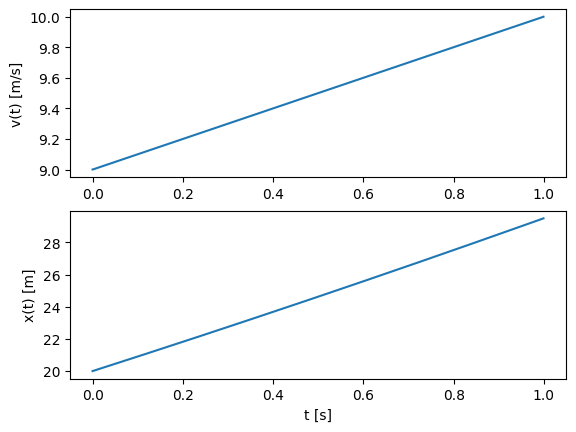

In [11]:
plt.figure()
plt.subplot(2,1,1)
plt.plot(cinematica.t, cinematica.v)
plt.ylabel("v(t) [m/s]")

plt.subplot(2,1,2)
plt.plot(cinematica.t, cinematica.x)
plt.ylabel("x(t) [m]")
plt.xlabel("t [s]")
plt.show()

Gráfico de la malla

/tmp/ipykernel_60537/3205954685.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


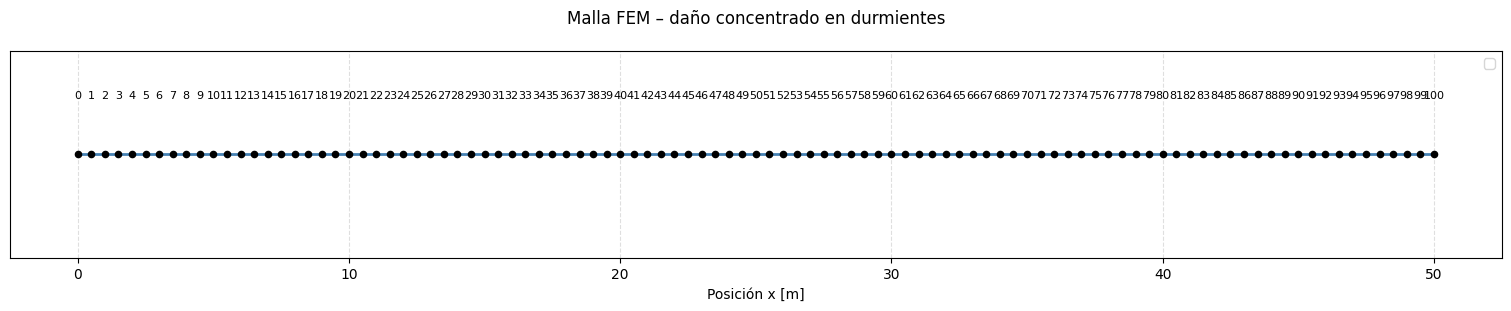

In [12]:
# Gráfico de la malla
fig, ax = plt.subplots(1, 1, figsize=(15, 3), constrained_layout=True)

# -----------------------------
# Dibujar elementos (TODOS sanos)
# -----------------------------
for ni, nj in malla.conect:
    x = [malla.coord_nodos[ni, 0], malla.coord_nodos[nj, 0]]
    y = [0, 0]
    ax.plot(x, y, color="steelblue", lw=2, zorder=1)

# -----------------------------
# Dibujar nodos
# -----------------------------
ax.scatter(
    malla.coord_nodos[:, 0],
    np.zeros(malla.n_tot),
    color="black",
    s=20,
    zorder=2
)

# -----------------------------
# Resaltar nodos dañados
# -----------------------------
if dano_nodal is not None:
    nodos_danados = list(dano_nodal.keys())
    factores = list(dano_nodal.values())

    x_d = malla.coord_nodos[nodos_danados, 0]

    # Tamaño proporcional al daño (opcional)
    sizes = [300 * (1 - f) + 50 for f in factores]

    ax.scatter(
        x_d,
        np.zeros(len(x_d)),
        color="red",
        s=sizes,
        edgecolors="black",
        zorder=3,
        label="Durmientes dañados"
    )

# -----------------------------
# Numerar nodos
# -----------------------------
for i, x in enumerate(malla.coord_nodos[:, 0]):
    ax.text(x, 0.03, str(i), ha="center", fontsize=8)

# -----------------------------
# Estética
# -----------------------------
ax.set_title("Malla FEM – daño concentrado en durmientes", pad=20)
ax.set_xlabel("Posición x [m]")
ax.set_yticks([])
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper right")

plt.show()

Integración de la ecuación diferencial

In [ ]:
load_or_calculate = 'calculate'

filename_sol = '/home/pablo/Facultad/Doctorado_UNCuyo/Salidas_modelo/prueba_27.pkl'
if load_or_calculate == 'calculate':
    start_time = time.time()
    print(f'{t_sim=}')
    sistema = SistemaViaVehiculo(
    via=via,
    tren=carga,
    sim=sim,
    cinem=cinematica,
    m_inv=m_inv
)
    sol = solve_ivp(
        sistema.rhs,
        (t_eval[0], t_eval[-1]),
        y0,
        t_eval=t_eval,
        method="Radau"
)

    end_time = time.time()
    tiempo_transcurrido = end_time - start_time
    print(f'Tiempo transcurrido: {tiempo_transcurrido} seg = {tiempo_transcurrido / 60} minutos')
    output = {
        "sol": sol,
        "sim": sim,
        "carga": carga,
        "via": via,
        "cinematica": cinematica
    }

    with open(filename_sol, 'wb') as file:
        pickle.dump(output, file)

elif load_or_calculate == 'load':
    with open(filename_sol, 'rb') as file:
        output = pickle.load(file)
    print(f'Solución cargada desde archivo: {filename_sol}')
    sol = output["sol"]
    sim = output["sim"]
    carga = output["carga"]
    via = output["via"]
    cinematica = output["cinematica"]

t_sim=1
Tiempo transcurrido: 361.1723368167877 seg = 6.019538946946462 minutos


In [14]:
sistema = SistemaViaVehiculo(
    via=via,
    tren=carga,
    sim=sim,
    cinem=cinematica,
    m_inv=m_inv
)

Post proceso: Cálculo de aceleraciones

In [15]:
def calcular_aceleraciones(sol, sistema):
    """
    Reconstruye aceleraciones a partir de la ecuación del movimiento:
        qdd = M^{-1} (F - C qd - K q)

    Parameters
    ----------
    sol : OdeResult
        Resultado de solve_ivp
    sistema : SistemaViaVehiculo
        Sistema que contiene via, carga, cinematica y m_inv

    Returns
    -------
    a : ndarray (ndof, nt)
        Aceleraciones
    """

    ndof = sistema.ndof
    nt = sol.y.shape[1]

    q  = sol.y[0:ndof, :]
    qd = sol.y[ndof:2*ndof, :]

    a = np.zeros((ndof, nt))

    for i, t in enumerate(sol.t):

        # -------------------------
        # Cinemática de la carga
        # -------------------------
        x_c = sistema.cinem.x_fun(t)

        # -------------------------
        # Ensamble instantáneo
        # -------------------------
        F, K, C = sistema.tren.evaluar(x_c)

        # -------------------------
        # Aceleración
        # -------------------------
        a[:, i] = sistema.m_inv @ (F - C @ qd[:, i] - K @ q[:, i])

    return a

Creación de DataFrames

In [16]:
sol_t = sol.t
sol_y = sol.y

n_q = sol.y.shape[0] // 2
q  = sol.y[:n_q, :]  # Posiciones [u, w, phi]
dq = sol.y[n_q:, :] # Velocidades [du_dt, dw_dt, dphi_dt]

# Indices:
idx_tren = np.arange(0, carga.gdl_ejes + 1)
idx_via = np.arange(carga.gdl_ejes + 1, q.shape[0], dof_malla)
idx_w = np.concatenate([idx_tren, idx_via])

w_tren = q[idx_tren, :] 
w_via = q[idx_via, :]

dw_tren = dq[idx_tren, :]
dw_via = dq[idx_via, :]

n_w_tren = w_tren.shape[0]
n_w_via = w_via.shape[0]

# Definición de los DataFrames de desplazamientos y velocidades
df_w_tren  = pd.DataFrame(w_tren.T,  index=sol_t, columns=[f"w_tren{i}"  for i in range(n_w_tren)])
df_w_via  = pd.DataFrame(w_via.T,  index=sol_t, columns=[f"w_via{i}"  for i in range(n_w_via)])
df_dw_tren  = pd.DataFrame(dw_tren.T,  index=sol_t, columns=[f"dw_tren{i}"  for i in range(n_w_tren)])
df_dw_via  = pd.DataFrame(dw_via.T,  index=sol_t, columns=[f"dw_via{i}"  for i in range(n_w_via)])


# aceleraciones
acel = calcular_aceleraciones(sol, sistema)

ddw_tren = acel[idx_tren, :]
ddw_via = acel[idx_via, :]

# DataFrame
df_ddw_tren = pd.DataFrame(ddw_tren.T, index=sol_t, columns=[f"ddw_tren{i}" for i in range(n_w_tren)])
df_ddw_via  = pd.DataFrame(ddw_via.T,  index=sol_t, columns=[f"ddw_via{i}"  for i in range(n_w_via)])

Gráficos desplazamientos vía-aceleración vagón, ambos en función del tiempo

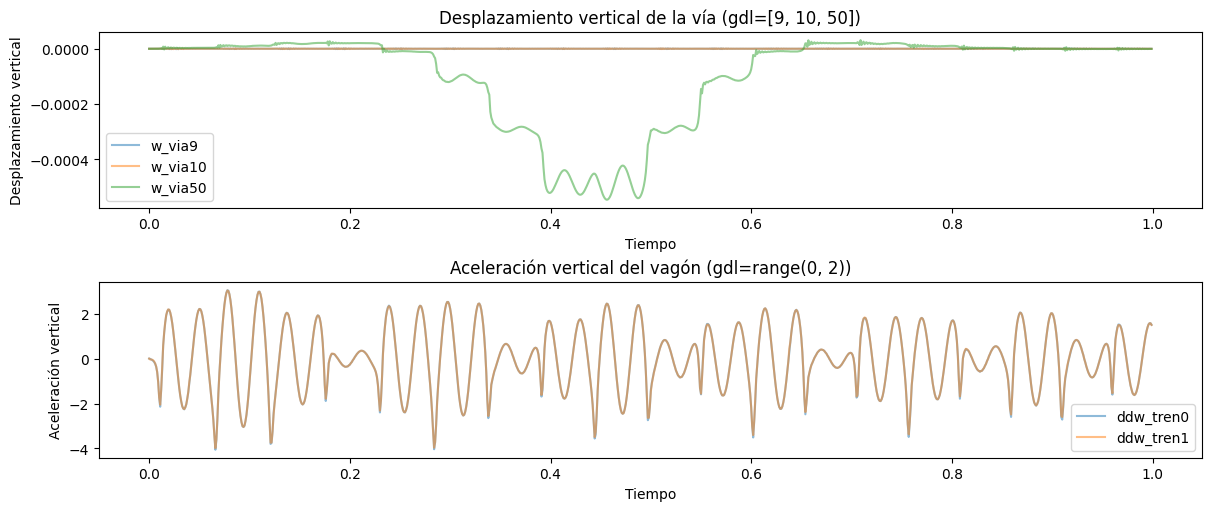

In [17]:
nodos_via = [9, 10, 50]

desp_via = pd.concat([df_w_tren.iloc[:, [0, 1, 2]], df_w_via.iloc[:, nodos_via]], axis=1) # Para ver desplazamientos de la vía y las masas del tren
desp_via = df_w_via.iloc[:, nodos_via]  # Para ver solo desplazamientos de la vía


fig, axs = plt.subplots(2, 1, figsize=(12, 5), constrained_layout=True)

desp_via.plot(ax=axs[0], alpha=0.5)
axs[0].set_xlabel("Tiempo")
axs[0].set_ylabel("Desplazamiento vertical")
axs[0].set_title(f"Desplazamiento vertical de la vía (gdl={nodos_via})")

# Segundo subplot → aceleraciones
gdl_acel_vagon = range(2)
acel_cols = df_ddw_tren.iloc[:, gdl_acel_vagon]
acel_cols.plot(ax=axs[1], alpha=0.5)
axs[1].set_xlabel("Tiempo")
axs[1].set_ylabel("Aceleración vertical")
axs[1].set_title(f"Aceleración vertical del vagón (gdl={gdl_acel_vagon})")
# plt.savefig("grafico.png", dpi=300, bbox_inches='tight')
plt.show()

Solo desplazamientos

Text(0.5, 1.0, 'Desplazamiento vertical del vagón (gdl=[0, 1])')

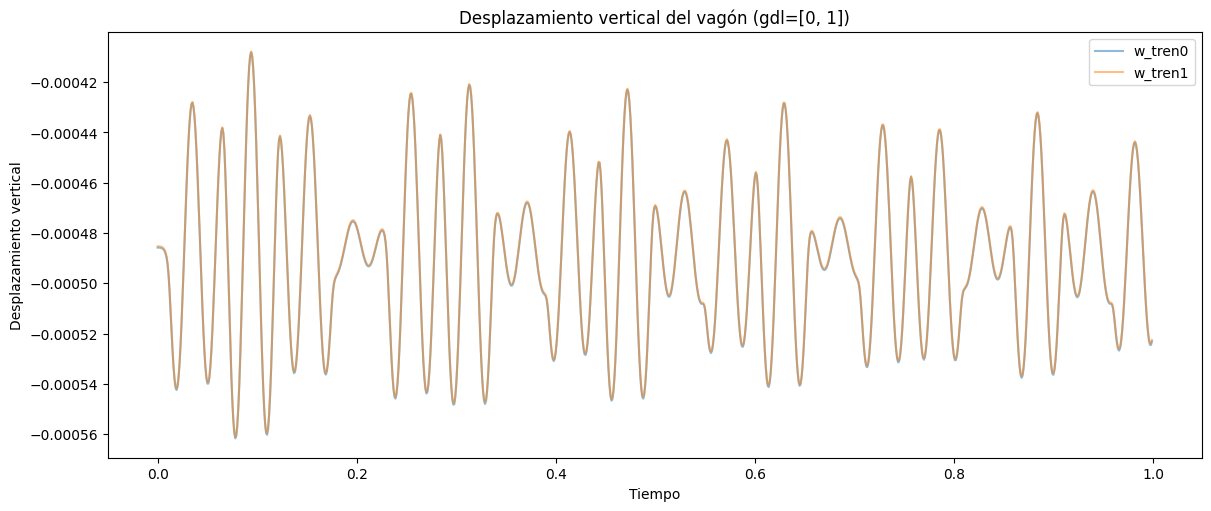

In [18]:
gdl = [0, 1]


desp = df_w_tren.iloc[:, gdl]

fig, axs = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)

desp.plot(ax=axs, alpha=0.5)
axs.set_xlabel("Tiempo")
axs.set_ylabel("Desplazamiento vertical")
axs.set_title(f"Desplazamiento vertical del vagón (gdl={gdl})")

Solo aceleraciones

Text(0.5, 1.0, 'Aceleraciones verticales del bogie (gdl=[0, 1])')

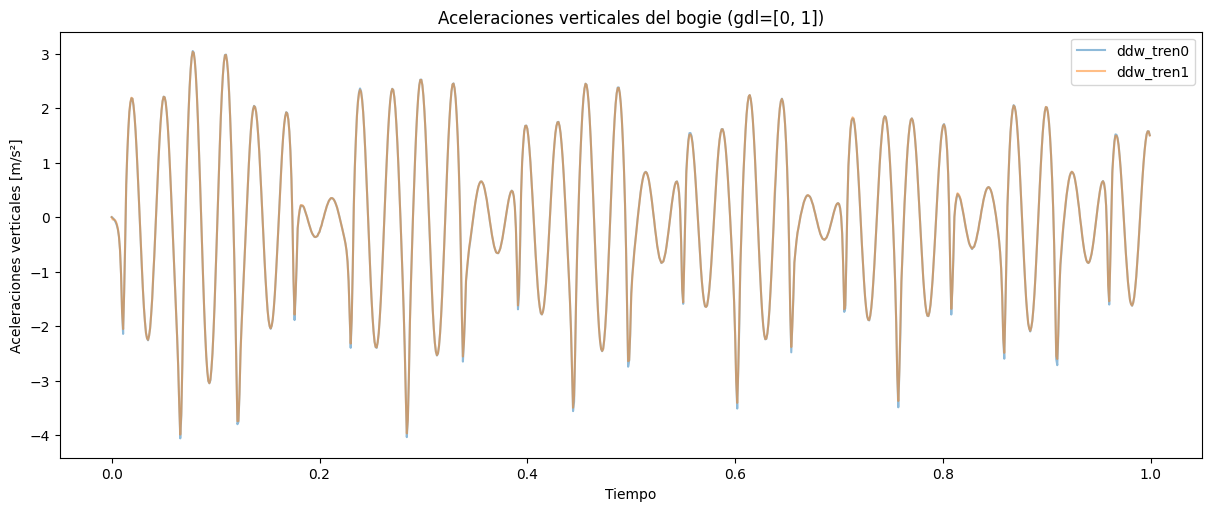

In [19]:
gdl = [0, 1]


acele = df_ddw_tren.iloc[:, gdl]

fig, axs = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)

acele.plot(ax=axs, alpha=0.5)
axs.set_xlabel("Tiempo")
axs.set_ylabel("Aceleraciones verticales [m/s²]")
axs.set_title(f"Aceleraciones verticales del bogie (gdl={gdl})")

Desplazamientos, velocidades y aceleraciones de la vía

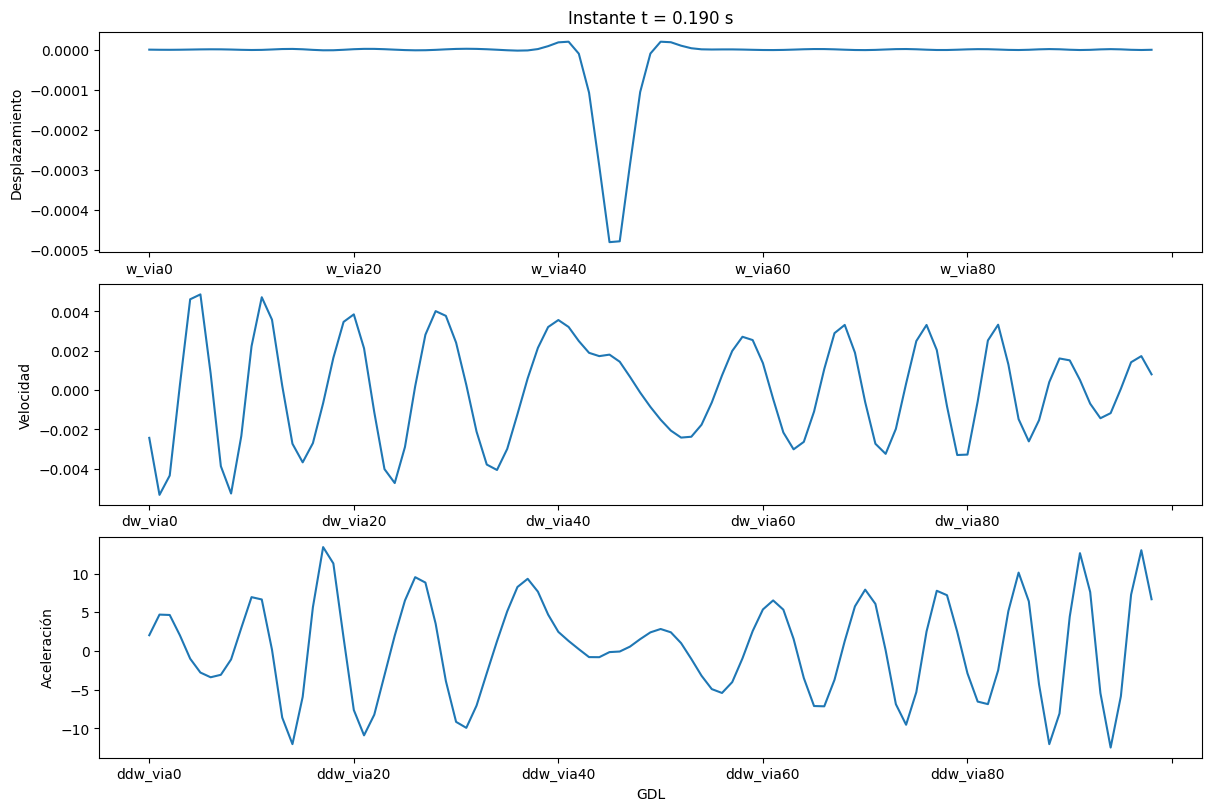

In [20]:
fig, axs = plt.subplots(3, 1, figsize=(12, 8), constrained_layout=True)
i = 190
w_i = df_w_via.iloc[i]
w_i.plot(ax=axs[0])
axs[0].set_ylabel("Desplazamiento")
axs[0].set_title(f"Instante t = {sol.t[i]:.3f} s")

dw_i = df_dw_via.iloc[i]
dw_i.plot(ax=axs[1])
axs[1].set_ylabel("Velocidad")

ddw_i = df_ddw_via.iloc[i]
ddw_i.plot(ax=axs[2])
axs[2].set_ylabel("Aceleración")
axs[2].set_xlabel("GDL")

plt.show()


Animación de desplazamientos

In [21]:
import plotly.graph_objects as go
from ipywidgets import IntSlider, VBox

# --- Ejes de tiempo
tiempos = df_w_tren.index.values
nt = len(tiempos)

dataframe = df_w_via

# --- Selección de GDL espaciales (vía)
cols_via = dataframe.columns[carga.gdl_ejes  + 1 :: dof_malla]

# --- Rango global para el eje Y (evita que "salte")
ymin = dataframe[cols_via].min().min()
ymax = dataframe[cols_via].max().max()

# --- Estado inicial (t = t0)
subset0 = dataframe.iloc[0][cols_via]

fig = go.FigureWidget(
    data=[
        go.Scatter(
            x=subset0.index,   # nodos / GDL espaciales
            y=subset0.values,
            mode="markers+lines"
        )
    ],
    layout=go.Layout(
        title=f"Instante t = {tiempos[0]:.3f} s",
        xaxis_title="GDL / Nodo",
        yaxis_title="w",
        yaxis=dict(range=[ymin, ymax])
    )
)

# --- Slider de tiempo
slider = IntSlider(
    min=0,
    max=nt - 1,
    step=1,
    value=0,
    description="t index"
)

def on_change(change):
    idx = change["new"]
    subset = dataframe.iloc[idx][cols_via]

    with fig.batch_update():
        fig.data[0].x = subset.index
        fig.data[0].y = subset.values
        fig.layout.title = f"Instante t = {tiempos[idx]:.3f} s"

slider.observe(on_change, names="value")

VBox([slider, fig])

    'data': [{'mode': 'marke…